### Content:
- compute average trip duration 
- plot number of trips per day
- plot count of number of trips for day of the week
- plot count of number of trips by hour of the day
- plot trips by hour for each operator: wind vs BIT e-scooters
- plot usage by month
- plot cumulative time of usage per day 



In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [40]:
df = pd.read_parquet('../data/trips_pointv3.parquet')

In [41]:
df

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,None
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,None
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,None
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,None
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,None
...,...,...,...,...,...,...,...,...
999995,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:41+00:00,46.079951,11.117475,3,None
999996,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:51+00:00,46.079677,11.117734,4,None
999997,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:01+00:00,46.079403,11.117844,5,None
999998,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:11+00:00,46.079176,11.117913,6,None


In [42]:
len(pd.unique(df.point_trip_id))

30443

### Average trip duration

In [43]:
new_df = df.groupby('point_trip_id', as_index=False).aggregate({"point_latitude": lambda x: x.to_list(),"point_longitude": lambda x: x.to_list(), "point_timestamp":lambda x: x.to_list()})
new_df["coords"] = [ [[k,v] for k,v in zip(i,j)] for i,j in zip(new_df["point_latitude"], new_df["point_longitude"])]
new_df

,point_trip_id,point_latitude,point_longitude,point_timestamp,coords
0,00000000-0000-1000-8000-5b7d6a617b60,"[46.060551, 46.071407, 46.075313, 46.090282, 4...","[11.115241, 11.119391, 11.123848, 11.115124, 1...","[2021-06-10 06:26:23+00:00, 2021-06-10 06:14:1...","[[46.060551, 11.115241], [46.071407, 11.119391..."
1,00000001-0000-1000-9ec1-5b7d6a617b60,"[46.060532, 46.060551, 46.071957, 46.060024, 4...","[11.115307, 11.115251, 11.120046, 11.133364, 1...","[2020-12-03 14:14:57+00:00, 2020-12-03 14:44:4...","[[46.060532, 11.115307], [46.060551, 11.115251..."
2,00000002-0000-1000-9672-5b7d6a617b60,"[46.083942, 46.062672, 46.061096, 46.073547, 4...","[11.119583, 11.127701, 11.114304, 11.115504, 1...","[2021-02-25 15:25:01+00:00, 2021-02-25 15:49:2...","[[46.083942, 11.119583], [46.062672, 11.127701..."
3,00000003-0000-1000-8e23-5b7d6a617b60,"[46.036368, 46.098608, 46.070222, 46.069969, 4...","[11.130376, 11.119523, 11.120388, 11.123241, 1...","[2022-02-01 21:01:50+00:00, 2022-02-01 21:30:5...","[[46.036368, 11.130376], [46.098608, 11.119523..."
4,00000004-0000-1000-85d4-5b7d6a617b60,"[46.061763, 46.063675, 46.066727, 46.059666, 4...","[11.115239, 11.119329, 11.120344, 11.115260, 1...","[2021-06-27 17:14:20+00:00, 2021-06-27 17:09:3...","[[46.061763, 11.115239], [46.063675, 11.119329..."
...,...,...,...,...,...
30438,fff6b734bab3,"[46.086395, 46.086609]","[11.119722, 11.119655]","[2021-04-22 17:10:48+00:00, 2021-04-22 17:10:5...","[[46.086395, 11.119722], [46.086609, 11.119655]]"
30439,fff737605a72,"[46.067649, 46.067703, 46.067703, 46.067703, 4...","[11.120356, 11.120315, 11.120315, 11.120315, 1...","[2021-07-19 11:37:12+00:00, 2021-07-19 11:37:3...","[[46.067649, 11.120356], [46.067703, 11.120315..."
30440,fff77d5c39b5,"[46.070156, 46.068747, 46.068745, 46.070084, 4...","[11.124863, 11.126074, 11.126060, 11.125454, 1...","[2021-06-07 16:25:44+00:00, 2021-06-07 16:26:3...","[[46.070156, 11.124863], [46.068747, 11.126074..."
30441,fff9fc12b926,"[46.078064, 46.077972]","[11.123182, 11.123108]","[2021-06-09 06:33:31+00:00, 2021-06-09 06:39:3...","[[46.078064, 11.123182], [46.077972, 11.123108]]"


In [44]:
new_df.point_timestamp[0]

[Timestamp('2021-06-10 06:26:23+0000', tz='UTC'),
 Timestamp('2021-06-10 06:14:15+0000', tz='UTC'),
 Timestamp('2021-07-31 16:48:36+0000', tz='UTC'),
 Timestamp('2021-08-05 19:57:00+0000', tz='UTC'),
 Timestamp('2021-07-31 17:03:30+0000', tz='UTC'),
 Timestamp('2021-08-05 19:37:04+0000', tz='UTC'),
 Timestamp('2021-09-28 17:29:15+0000', tz='UTC'),
 Timestamp('2021-09-28 17:41:19+0000', tz='UTC'),
 Timestamp('2021-10-01 19:34:39+0000', tz='UTC'),
 Timestamp('2021-10-01 19:37:58+0000', tz='UTC')]

In [45]:
df[df.point_trip_id =='00000001-0000-1000-9ec1-5b7d6a617b60'] ## how is it that the same ID appears in different days? does it mean it's the same person?

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability
80744,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2020-12-03 14:14:57+00:00,46.060532,11.115307,0,None
80974,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2020-12-03 14:44:40+00:00,46.060551,11.115251,1,None
93023,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-02-16 15:05:28+00:00,46.071957,11.120046,0,None
97117,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-02-16 15:15:17+00:00,46.060024,11.133364,1,None
101247,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-03-20 20:52:02+00:00,46.061253,11.126844,1,None
102618,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-03-20 20:14:08+00:00,46.061020,11.124775,0,None
112022,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-05-04 14:19:43+00:00,46.073273,11.126663,0,None
116615,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-05-04 14:24:13+00:00,46.082153,11.122440,1,None
119678,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-05-19 17:48:56+00:00,46.083977,11.119506,0,None
119679,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-05-19 17:55:59+00:00,46.069721,11.121650,1,None


try differently: build dictionary with all timestamps per trip (some are different trips even if same id)

In [46]:
df

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,None
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,None
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,None
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,None
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,None
...,...,...,...,...,...,...,...,...
999995,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:41+00:00,46.079951,11.117475,3,None
999996,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:51+00:00,46.079677,11.117734,4,None
999997,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:01+00:00,46.079403,11.117844,5,None
999998,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:11+00:00,46.079176,11.117913,6,None


In [47]:
d={}
for row in range(len(df)):
  if df.point_trip_id[row] not in d.keys():
    inner_df={}
    inner_df[df.point_sequence[row]]=df.point_timestamp[row]
    d[df.point_trip_id[row]] = inner_df
  else:
    if df.point_sequence[row] not in d[df.point_trip_id[row]]:
      d[df.point_trip_id[row]][df.point_sequence[row]]=df.point_timestamp[row]
    else:
      if df.point_trip_id[row]+'+1' not in d.keys():
        inner_df={}
        inner_df[df.point_sequence[row]]=df.point_timestamp[row]
        d[df.point_trip_id[row]+'+1'] = inner_df
      else:
        d[df.point_trip_id[row]+'+1'][df.point_sequence[row]]=df.point_timestamp[row]

In [48]:
# d={}
# for row in range(len(df)):
#   if df.point_trip_id[row] not in d.keys():
#     inner_df={}
#     inner_df[float(df.point_sequence[row])]=str(df.point_timestamp[row])
#     d[df.point_trip_id[row]] = inner_df
#   else:
#     if float(df.point_sequence[row]) not in d[df.point_trip_id[row]]:
#       d[df.point_trip_id[row]][float(df.point_sequence[row])]=str(df.point_timestamp[row])
#     else:
#       if df.point_trip_id[row]+'+1' not in d.keys():
#         inner_df={}
#         inner_df[float(df.point_sequence[row])]=str(df.point_timestamp[row])
#         d[df.point_trip_id[row]+'+1'] = inner_df
#       else:
#         d[df.point_trip_id[row]+'+1'][float(df.point_sequence[row])]=str(df.point_timestamp[row])



# import os
# import sys 
# from google.colab import drive 
# import glob

# path = "/content/drive" 
# drive.mount(path, force_remount=True)  
# data_path = "drive/MyDrive/Colab Notebooks" 

# myfiles = glob.glob(os.path.join(data_path, '*')) 
# print(myfiles)



# import json
    
# with open(data_path+'/all_trips_timestamps.json', 'w', encoding='utf-8') as file:
#   json.dump(d, file)

In [49]:
l=[]
for k in d.keys():
  duration = d[k][max(d[k].keys())] - d[k][min(d[k].keys())]
  l.append((k, duration))
l

[('24c83c4e-1e60-4b65-9100-8cf1550076df', Timedelta('0 days 00:06:40')),
 ('1dac7a0b-0ab2-4f61-8b5b-01f8ad49b5ce', Timedelta('0 days 00:08:02')),
 ('ca12a6aa-ec84-40d9-a6f2-a98e2c24cd26', Timedelta('0 days 00:02:44')),
 ('da0a08f3-5bc2-40c3-9ee7-f2ef0b68905b', Timedelta('0 days 00:06:09')),
 ('546cad2e-5cf3-496c-9182-e7caa4bff556', Timedelta('0 days 00:15:05')),
 ('00000b31-0000-1000-9801-5b7d6a617b60', Timedelta('0 days 00:06:20')),
 ('0000125a-0000-1000-9cba-5b7d6a617b60', Timedelta('-292 days +01:31:27')),
 ('00000ade-0000-1000-8a7e-5b7d6a617b60', Timedelta('0 days 00:07:11')),
 ('000003fa-0000-1000-926a-5b7d6a617b60', Timedelta('0 days 00:02:10')),
 ('000015a5-0000-1000-90c5-5b7d6a617b60', Timedelta('0 days 00:11:24')),
 ('000020a9-0000-1000-9809-5b7d6a617b60', Timedelta('0 days 00:14:46')),
 ('00002032-0000-1000-a432-5b7d6a617b60', Timedelta('20 days 06:46:30')),
 ('00001789-0000-1000-92d9-5b7d6a617b60', Timedelta('0 days 00:12:05')),
 ('00000c32-0000-1000-a522-5b7d6a617b60', Time

In [50]:
s=pd.Timedelta('0')
for el in l:
  s+=el[1]
avg=s/len(l)

print(avg)

print('The average trip is approximately %d minutes long.' % int((avg.seconds//60)%60))

0 days 00:05:08.132112362
The average trip is approximately 5 minutes long.


### Number of trips per day

In [51]:
d=[]
for row in range(len(df)):
  gg=df.point_timestamp[row].date()
  d.append(gg)
df['date']=d
df

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,date
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,None,2022-01-07
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,None,2022-01-07
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,None,2022-01-07
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,None,2022-01-07
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,None,2022-01-07
...,...,...,...,...,...,...,...,...,...
999995,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:41+00:00,46.079951,11.117475,3,None,2022-03-04
999996,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:51+00:00,46.079677,11.117734,4,None,2022-03-04
999997,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:01+00:00,46.079403,11.117844,5,None,2022-03-04
999998,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:11+00:00,46.079176,11.117913,6,None,2022-03-04


In [52]:
daily_trips = df.groupby('date', as_index=False).aggregate({"point_sequence": lambda x: x.to_list()})

cnt=[]
for el in range(len(daily_trips)):
  cnt.append(daily_trips.point_sequence[el].count(0))

daily_trips['num_trips']=cnt
daily_trips=daily_trips.drop(['point_sequence'], axis=1)
  
daily_trips.head()

,date,num_trips
0,2020-11-30,21
1,2020-12-01,87
2,2020-12-02,60
3,2020-12-03,80
4,2020-12-04,43


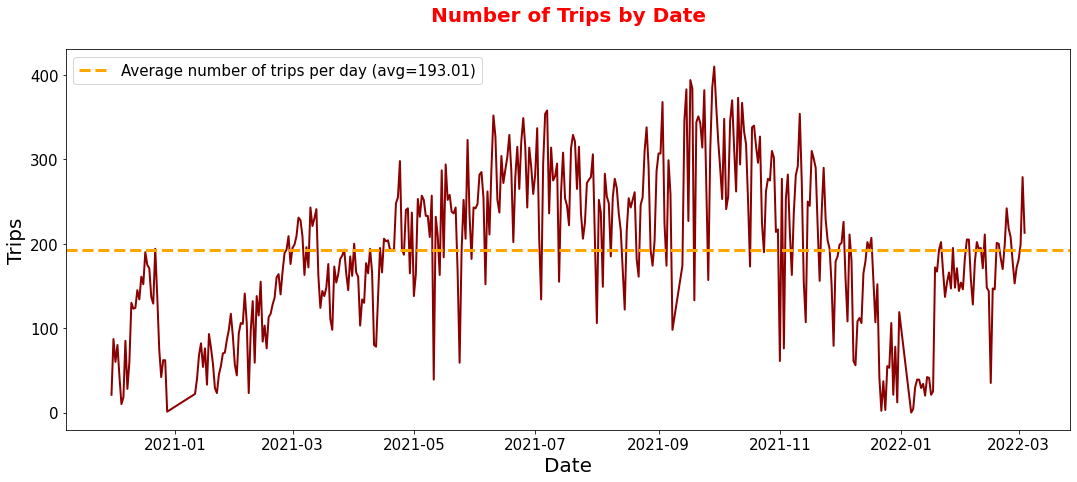

In [53]:
plt.figure(figsize = (18, 7))
plot = sns.lineplot(x = "date", y = "num_trips", data = daily_trips, color = "darkred", linewidth = 2)
avg_trips_num = daily_trips["num_trips"].mean()
plot.axhline(avg_trips_num, linestyle="--", color="orange", label="Average number of trips per day (avg="+str(round(avg_trips_num,2))+')', linewidth = 3) 
plt.title("Number of Trips by Date\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Date", size = 20, color = 'black')
plt.ylabel("Trips", size = 20, color = 'black')
plt.legend(prop={'size': 15})
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Number of trips by week day

In [54]:
df['day'] = df['point_timestamp'].dt.day_name()
df.head()

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,date,day
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,None,2022-01-07,Friday
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,None,2022-01-07,Friday
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,None,2022-01-07,Friday
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,None,2022-01-07,Friday
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,None,2022-01-07,Friday


In [55]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
trip_by_weekday = df.groupby('day')['day'].agg(["count"]).reindex(days).reset_index()
trip_by_weekday.columns = ["day_of_week", "num_trips"]
trip_by_weekday

,day_of_week,num_trips
0,Monday,141298
1,Tuesday,144852
2,Wednesday,145359
3,Thursday,155571
4,Friday,155700
5,Saturday,141373
6,Sunday,115847


In [56]:
trip_by_weekday["num_trips"].mean()

142857.14285714287

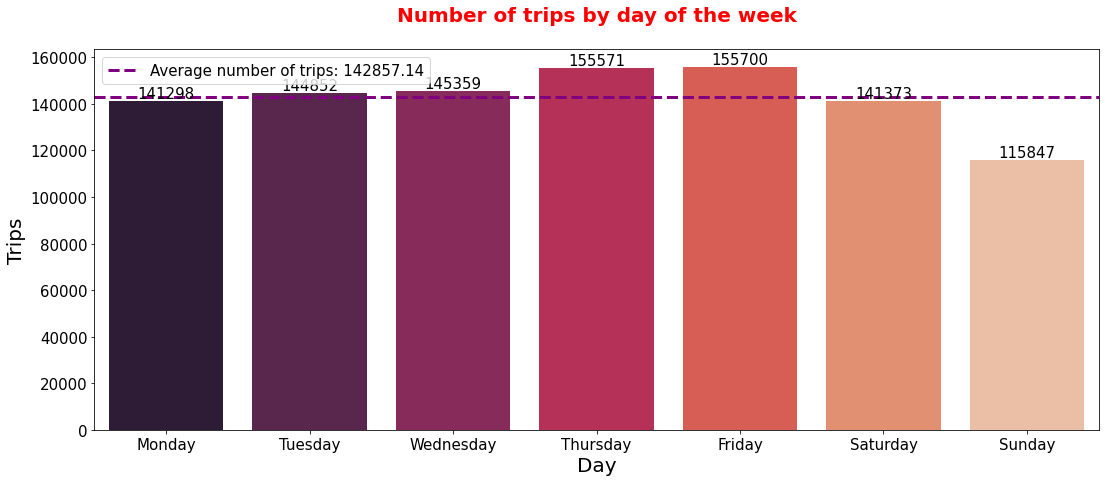

In [57]:
plt.figure(figsize = (18, 7))
plot = sns.barplot(x = "day_of_week", y = "num_trips", data = trip_by_weekday, palette = "rocket")
for p in plot.patches:
  plot.annotate('{:.0f}'.format(p.get_height()),
                (p.get_x()+0.4, p.get_height()),
                ha='center', va='bottom',color= 'black', size = 15)
plot.axhline(trip_by_weekday["num_trips"].mean(), linestyle="--", color="purple", label="Average number of trips: "+str(round(trip_by_weekday["num_trips"].mean(),2)), linewidth = 3) 
plt.title("Number of trips by day of the week\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Day", size = 20, color = 'black')
plt.ylabel("Trips", size = 20, color = 'black')
plt.legend(prop={'size': 15})
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Trips by hour of the day

In [58]:
df['hour'] = df['point_timestamp'].dt.hour

trip_by_h = df['hour'].value_counts().to_frame().reset_index()
trip_by_h.columns = ['hour', 'num_trips']

trip_by_h

,hour,num_trips
0,16,91665
1,17,89870
2,15,84540
3,14,74436
4,18,73812
5,10,73726
6,11,71343
7,13,69812
8,12,69482
9,19,62371


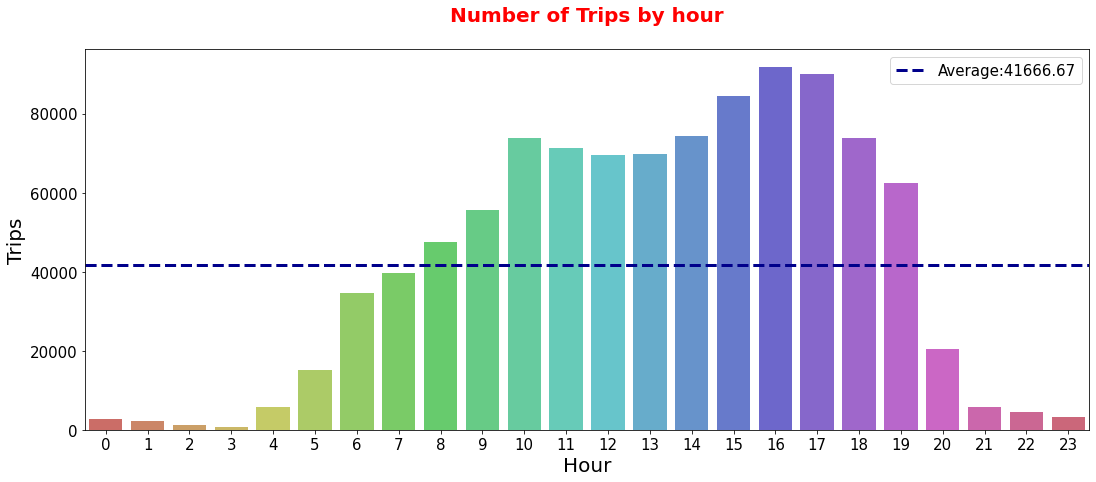

In [59]:
plt.figure(figsize = (18, 7))
plot = sns.barplot(x = 'hour', y = 'num_trips', data = trip_by_h, palette = "hls")
plot.axhline(trip_by_h['num_trips'].mean(), linestyle="--", color="darkblue", label="Average:"+str(round(trip_by_h['num_trips'].mean(), 2)), linewidth = 3) 
plt.title("Number of Trips by hour\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Hour", size = 20, color = 'black')
plt.ylabel("Trips", size = 20, color = 'black')
plt.legend(prop={'size': 15})
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Number of trips by the two different operators

In [60]:
pd.unique(df.operator)

array(['VENTO', 'BIT'], dtype=object)

In [61]:
op = df.groupby(['operator', 'hour'])['operator'].agg(["count"]).reset_index()
op.columns = ['operator', 'hour', 'num_trips']
op

,operator,hour,num_trips
0,BIT,0,293
1,BIT,1,220
2,BIT,2,147
3,BIT,3,125
4,BIT,4,761
5,BIT,5,3227
6,BIT,6,6724
7,BIT,7,6283
8,BIT,8,5780
9,BIT,9,6330


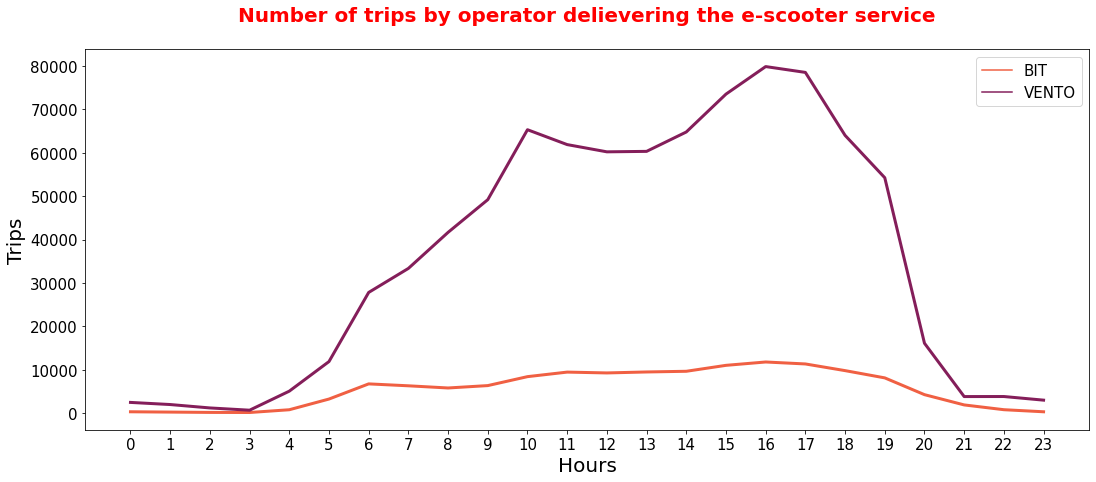

In [62]:
plt.figure(figsize = (18, 7))
sns.lineplot(x = 'hour', y = 'num_trips', hue = 'operator', data = op, palette = "rocket_r", linewidth = 3) 
plt.title("Number of trips by operator delievering the e-scooter service\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Hours", size = 20, color = "black")
plt.ylabel("Trips", size = 20, color = "black")
plt.legend(prop={'size': 15})
plt.xticks(range(0,24), size = 15)
plt.yticks(size = 15)
plt.show()

### Usage by month

In [63]:
df['month'] = pd.to_datetime(df['date']).dt.month
df.head()

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,date,day,hour,month
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,None,2022-01-07,Friday,20,1
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,None,2022-01-07,Friday,20,1
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,None,2022-01-07,Friday,20,1
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,None,2022-01-07,Friday,20,1
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,None,2022-01-07,Friday,20,1


In [64]:
m = df.groupby(['month', 'hour'])['month'].agg(["count"]).reset_index()
m.columns = ['month', 'hour', 'num_trips']
m.head()

,month,hour,num_trips
0,1,0,716
1,1,1,797
2,1,2,383
3,1,3,358
4,1,4,191


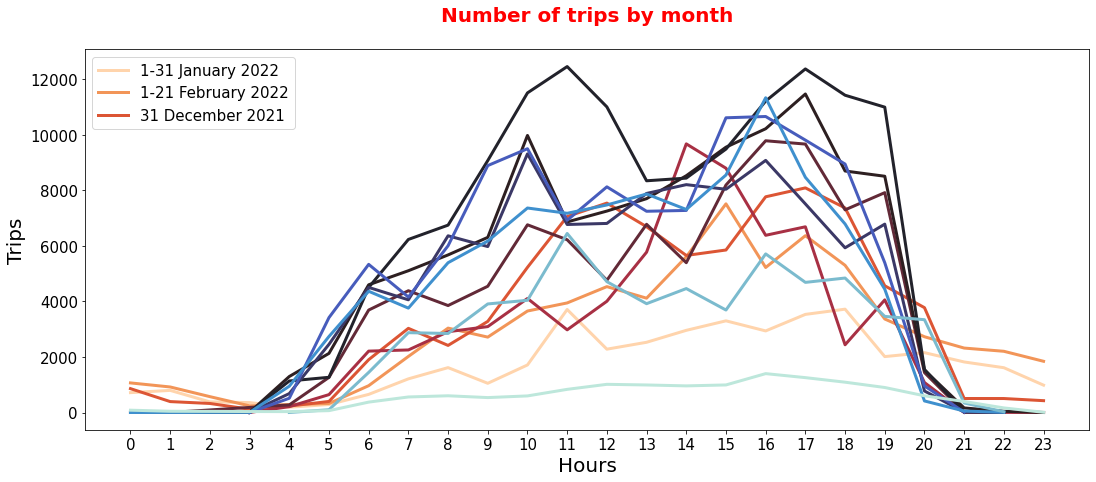

In [65]:
plt.figure(figsize = (18, 7))
sns.lineplot(x = 'hour', y = 'num_trips', hue = 'month', data = m, palette = "icefire_r", linewidth = 3) 
plt.title("Number of trips by month\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Hours", size = 20, color = "black")
plt.ylabel("Trips", size = 20, color = "black")
plt.legend(['1-31 January 2022', '1-21 February 2022', '31 December 2021'], prop={'size': 15})
plt.xticks(range(0,24), size = 15)
plt.yticks(size = 15)
plt.show()

### Cumulative time of usage per day

(may add cumulative time of usage per day **per scooter**)

In [66]:
df['day'] = pd.to_datetime(df['date']).dt.day
df.head()

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,date,day,hour,month
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,None,2022-01-07,7,20,1
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,None,2022-01-07,7,20,1
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,None,2022-01-07,7,20,1
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,None,2022-01-07,7,20,1
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,None,2022-01-07,7,20,1


In [68]:
d={}
for row in range(len(df)):
  if df.point_trip_id[row] not in d.keys():
    inner_df={}
    inner_df[df.point_sequence[row]]=df.point_timestamp[row]
    d[df.point_trip_id[row]] = inner_df
  else:
    if df.point_sequence[row] not in d[df.point_trip_id[row]]:
      d[df.point_trip_id[row]][df.point_sequence[row]]=df.point_timestamp[row]
    else:
      if df.point_trip_id[row]+'+1' not in d.keys():
        inner_df={}
        inner_df[df.point_sequence[row]]=df.point_timestamp[row]
        d[df.point_trip_id[row]+'+1'] = inner_df
      else:
        d[df.point_trip_id[row]+'+1'][df.point_sequence[row]]=df.point_timestamp[row]

# for each trip, record date and trip duration
duration=[]
day=[]
for k in d.keys():
  duration.append(d[k][max(d[k].keys())] - d[k][min(d[k].keys())])
  day.append(pd.to_datetime(d[k][0]).date())

drtn = pd.DataFrame({'day':day, 'duration':duration})
drtn

KeyError: 0

In [ ]:
# cumulative duration of trips, for each date
drtn_by_day = drtn.groupby(['day'])['duration'].agg(["sum"]).reset_index()
drtn_by_day.columns = ['day', 'cumduration']
drtn_by_day.head()

,day,cumduration
0,2021-12-31,0 days 02:34:15
1,2022-01-01,0 days 19:00:40
2,2022-01-02,0 days 12:44:09
3,2022-01-03,0 days 23:21:37
4,2022-01-04,1 days 00:31:27


In [ ]:
drtn_by_day['cumduration_time']=(pd.Timestamp('now').normalize() + drtn_by_day.cumduration).dt.time # pd.Timestamp('now').normalize() -> reset to midnight

In [ ]:
drtn_by_day['cumduration_int'] = round(drtn_by_day.cumduration.dt.seconds / 60, 0)
drtn_by_day['cumduration_int'] = drtn_by_day['cumduration_int'].astype('int64', copy=False)
drtn_by_day.head()

,day,cumduration,cumduration_time,cumduration_int
0,2021-12-31,0 days 02:34:15,02:34:15,154
1,2022-01-01,0 days 19:00:40,19:00:40,1141
2,2022-01-02,0 days 12:44:09,12:44:09,764
3,2022-01-03,0 days 23:21:37,23:21:37,1402
4,2022-01-04,1 days 00:31:27,00:31:27,31


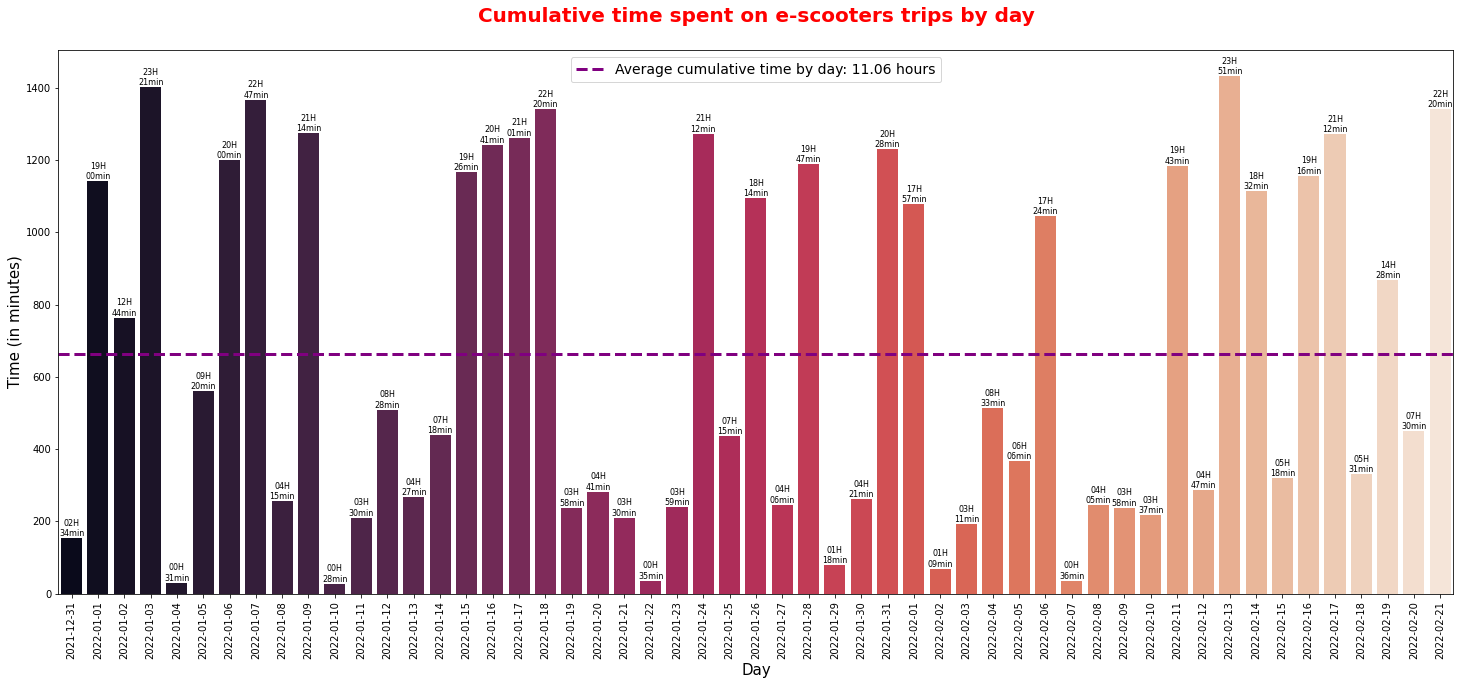

In [ ]:
plt.figure(figsize = (25, 10))
plot = sns.barplot(x = "day", y = "cumduration_int", data = drtn_by_day, palette = "rocket")
for p in range(len(plot.patches)):
  plot.annotate(str(drtn_by_day.cumduration_time[p])[:2]+'H\n'+str(drtn_by_day.cumduration_time[p])[3:5]+'min', 
                (plot.patches[p].get_x()+0.4, plot.patches[p].get_height()),
                ha='center', va='bottom',color= 'black', size = 8)
plot.axhline(drtn_by_day["cumduration_int"].mean(), linestyle="--", color="purple", label="Average cumulative time by day: "+str(round(drtn_by_day["cumduration_int"].mean()/60,2))+' hours', linewidth = 3) 
plt.title("Cumulative time spent on e-scooters trips by day\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Day", size = 15, color = 'black')
plt.ylabel("Time (in minutes)", size = 15, color = 'black')
plt.legend(prop={'size': 14}, loc='upper center')
plt.xticks(size = 10, rotation=90)
plt.yticks(size = 10)
plt.show()